In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import sin, radians 
from uncertainties.umath import *

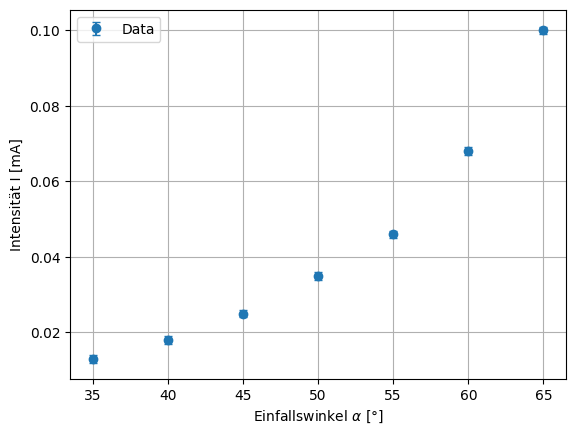

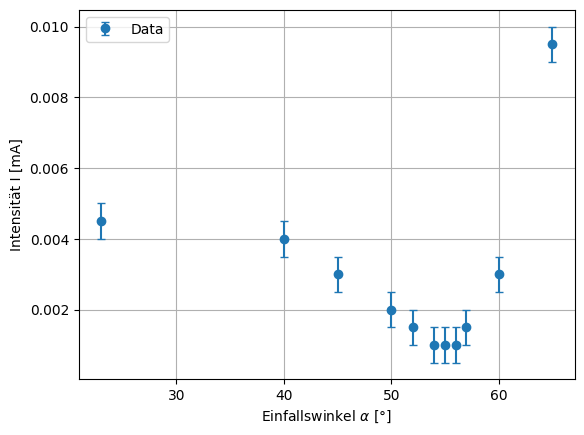

Brewsterwinkel: 55 +/- 2 [°]; 0.9599310885968813 +/- 0.03490658503988659 [rad]
Brechungsindex Platte: 1.4281480067421144 +/- 0.10610229077928651


In [2]:
# 1. Brewster Winkel

#senkrechte Polarisation
I_senk = unp.uarray([0.013, 0.018, 0.025, 0.035, 0.046, 0.068, 0.1], 0.001)           #[[mA] gemessene Intensität bei senkrechtem Lichteinfall
alpha_senk = np.array([35, 40, 45, 50, 55, 60, 65])         #[°] Einfallswinkel


#plot senkrecht
I_senk_nom  = unp.nominal_values(I_senk)
I_senk_u = unp.std_devs(I_senk)

plt.figure()
plt.errorbar(alpha_senk, I_senk_nom, yerr=I_senk_u, fmt='o', capsize=3, label="Data")
plt.xlabel(r"Einfallswinkel $\alpha$ [°]")
plt.ylabel(r"Intensität I [mA]")
plt.legend()
plt.grid(True)
plt.show()

#parallele Polarisation
I_par = unp.uarray([0.0045, 0.004, 0.003, 0.002, 0.0015, 0.001, 0.001, 0.001, 0.0015, 0.003, 0.0095], 0.0005)            #[mA] Intensität bei paralleler Polarisation
alpha_par = np.array([23, 40, 45, 50, 52, 54, 55, 56, 57, 60, 65])          #[°] Einfalsswinkel; bei Mimimum noch Messwerte hinzufügen


#plot parallel
I_par_nom = unp.nominal_values(I_par)
I_par_u = unp.std_devs(I_par)

# coeffs = np.polyfit(alpha_par, I_par, 3)                #evtl kubisch fitten? je nachdem wie die werte ausschauen
# poly = np.poly1d(coeffs)

# alpha_fit = np.linspace(np.min(alpha_par), np.max(alpha_par), 300)
# I_fit = poly(alpha_fit)


plt.figure()
plt.errorbar(alpha_par, I_par_nom, yerr=I_par_u, fmt='o', capsize=3, label="Data")
#plt.plot(alpha_fit, I_fit, linestyle='--', label="cubic fit")
plt.xlabel(r"Einfallswinkel $\alpha$ [°]")
plt.ylabel(r"Intensität I [mA]")
plt.legend()
plt.grid(True)
plt.show()


#berechnung brewster winkel
I_min = np.argmin(I_par_nom)        #index von kleinsten intensitärswert
alpha_B = 55          #brewster winkel: dort wo die Intensität minimal ist
alpha_B_u = 2                       #abgeschätze Unsicherheit vom brewster winkel 


alpha_B_rad = np.deg2rad(alpha_B)       #[°] -->[rad]
alpha_B_u_rad = np.deg2rad(alpha_B_u)   #[°] -->[rad]

n1 = 1                              #Brechungsindex Luft (oder Vakuum verwenden? --> fragen)

n2 = n1 * np.tan(alpha_B_rad)       #Brechungsindexplatte
n2_u = (1 / (np.cos(alpha_B_rad)**2)) * alpha_B_u_rad           #Unsicherheit Brechungsindex platte (Ka wieso - abegschrieben von aleks)


#ergebnisse printen

print(f"Brewsterwinkel: {alpha_B} +/- {alpha_B_u} [°]; {alpha_B_rad} +/- {alpha_B_u_rad} [rad]")
print(f"Brechungsindex Platte: {n2} +/- {n2_u}")




In [3]:
# 2. Spannungsoptik

#Werte
lam = 590 * 10**(-6)             #[nm] --> [mm] Wellenlänge verwendetes Licht

A_kolben =  (75/2)**2 * np.pi               #kolbenfläche Hydraulikpresse [mm²]
print(f"A kolben: {A_kolben}")

l1 = ufloat(10.5, 0.05)             #Seitenlänge 1 der Probe [mm]
l2 = ufloat(10.00, 0.05)             #Seitenlänge 2 der Probe [mm]
A_probe = l1 * l2           #Oberfläche der Probe [mm²]
print(f"A Probe: {A_probe}")
print()

d = l1             #Dicke der probe am Weg den das Licht nimmt [mm]

p_kolben = unp.uarray([3, 6.5-3, 10.5-6.5, 14-10.5], 0.5)*10**5         #Druck auf den Kolben der Presse bei verschiedenen Ordnungen (0, 1, 2) [Pa]

order = np.array([0, 1, 2, 3])


#sigma, C und S berechnen
sigma = (p_kolben * A_kolben) / A_probe     #Druck auf die Probe bei verschiedenen Ordnungen [Pa] 

C = lam / (sigma * d)                       #[1/Pa] Materialkonstante
C_nom = unp.nominal_values(C)
C_mean = np.mean(C)

C_mean_nom = np.mean(C_nom)
C_u = np.std(C_nom)/np.sqrt(len(C_nom))
C_ges = ufloat(C_mean_nom, C_u)


S = (lam / C_mean) * 10**(-6)                           #[N/mm] Spannungsoptische Konstante
#S_ges = lam / C_ges



#werte ausgeben
df = pd.DataFrame({
    "ordnung": order,
    "delta p_kolben [Pa]": p_kolben,
    "sigma_probe [Pa]": sigma,
    "C [1/Pa]": C,
    "S [N/mm]": S
})

display(df)
print()
print(f"C Mittelwert: {C_mean} [1/Pa]")
print(f"C Mittelwert +/- std d Mittelwert: {C_ges} [1/Pa]")
print(f"S Endwert: {S} [N/mm]")

A kolben: 4417.864669110647
A Probe: 105.0+/-0.7



,ordnung,delta p_kolben [Pa],sigma_probe [Pa],C [1/Pa],S [N/mm]
0,0,(3.0+/-0.5)e+05,(1.26+/-0.21)e+07,(4.5+/-0.7)e-12,153+/-11
1,1,(3.5+/-0.5)e+05,(1.47+/-0.21)e+07,(3.8+/-0.5)e-12,153+/-11
2,2,(4.0+/-0.5)e+05,(1.68+/-0.21)e+07,(3.3+/-0.4)e-12,153+/-11
3,3,(3.5+/-0.5)e+05,(1.47+/-0.21)e+07,(3.8+/-0.5)e-12,153+/-11



C Mittelwert: (3.86+/-0.29)e-12 [1/Pa]
C Mittelwert +/- std d Mittelwert: (3.86+/-0.20)e-12 [1/Pa]
S Endwert: 153+/-11 [N/mm]


In [4]:
# 3. Drehung der Polarisationsebene (Optische Aktivität)

print("quarz 1: rechts")
print("quarz 2: links")
print("quarz 3: rechts")
print()

#beim quarz nur schauen ob im/gegen Uhrezeigersinn (= rechts/links drehend)

#Drehwinkel Zuckerlösung
mw = ufloat(20.6, 0.1)                 #[g = ml] Masse Wasser; sollen ca 20g sein
ms = ufloat(2.0, 0.1)                 #[g] Masse Zucker; sollen ca. 2g sein
C = ms / mw                     #Verhältnis = Konzentration; [g/ml]
länge = ufloat(2, 0.2)                    #[dm] Länge der Küvette, gegeben (MUSS dm sein  - Konvention)

a0 = ufloat(0, 0.5)             #[°]; Winkel bei neutraler Position
ae = ufloat(13, 0.5)             #[°]; Winkel nach Messung (erneut dunkles Bild)
a = ae - a0                     #[°]; Winkel um den verdreht wurde = Drehwinkel; WICHTIG! WENIGER als 20°

a_spez = a / (C * länge)               #spezifischer Drehwinkel; [°/dm]

#Ergebnisse ausgeben
print(f"Konzentration Zuckerlösung: {C} [g/ml]")
print(f"alpaha: {a} [°]")
print(f"spezifischer Drehwinkel Zuckerlösung: {a_spez} [°/dm]")
print("Drehsinn: Rechtsdrehend/im Uhrzeigesinn")
print()
print("Literatur wert: 66.5 [°/dm]")

#Außerdem DRehrichtung notieren: ENTGEGENGESETZT der Richtung in die sich der Nonius gedreht hat!!



quarz 1: rechts
quarz 2: links
quarz 3: rechts

Konzentration Zuckerlösung: 0.097+/-0.005 [g/ml]
alpaha: 13.0+/-0.7 [°]
spezifischer Drehwinkel Zuckerlösung: 67+/-8 [°/dm]
Drehsinn: Rechtsdrehend/im Uhrzeigesinn

Literatur wert: 66.5 [°/dm]
